# Extended Data Figure 7

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy import stats

# remove top and right axis from plots
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top'] = False

# Specify data structure (30°/s edges only):
fs = 1000 # sampling frequency (Hz)
stims = ['on', 'off'] # stimuli
dirs = ['pd', 'nd']   # directions
tf = 8000             # timeframe (ms)

# Load input cell voltage data from Fig. 3:
os.chdir('../Fig. 3')
Mi9a = np.load('fig3_Mi9.npy')
Tm3a = np.load('fig3_Tm3.npy')
Mi1a = np.load('fig3_Mi1.npy')
Mi4a = np.load('fig3_Mi4.npy')
C3a = np.load('fig3_C3.npy')
os.chdir('../ED Fig. 7')

# Average input cell voltage data:
Mi9_ = np.nanmean(Mi9a, axis=1)
Tm3_ = np.nanmean(Tm3a, axis=1)
Mi1_ = np.nanmean(Mi1a, axis=1)
Mi4_ = np.nanmean(Mi4a, axis=1)
C3_ = np.nanmean(C3a, axis=1)

# Model parameters:
# Synaptic weights/gains:
Mi9gain = 0.92
Tm3gain = 0.35
Mi1gain = 0.65
Mi4gain = 1.1
C3gain = 1.49

# Thresholds:
Mi9trld = 0.20
Tm3trld = 0.35
Mi1trld = 0.88 
Mi4trld = 0.44
C3trld = 0.70

# Leak conductance:
gleak = 0.50
Eleak = -65.0

params = np.array([Mi9gain, Tm3gain, Mi1gain, Mi4gain, C3gain,
                   Mi9trld, Tm3trld, Mi1trld, Mi4trld, C3trld,
                   Eleak, gleak])

# Constants:
EGlu = -71.0    # Glutamate current reversal potential (mV)
EGABA   = -68.0 # GABA current reversal potential (mV)
EnAChR = -21.0  # Nicotinic acetycholine current reversal potential (mV)


# Min-max noramlization:
def normalize(a):
    anorm=a-np.min(a)
    anorm=anorm/np.max(anorm)
    return anorm


# Rectilinear transfer function:
def rect(x,thrld):
    result = x - thrld
    result = result * (result>0)
    result = result + thrld
    return result


# Time shift:
def shift_data(data, shift):
    shifted = np.roll(data, shift)
    if shift > 0:
        shifted[0:shift] = data[0]
    if shift < 0:
        shifted[int(len(data))+shift:int(len(data))] = data[-1]
    return shifted


# Calculate time shift for all directions:
def dir_shift(onoff=[1,1,1,1,1,1], Mi9_=normalize(Mi9_), Tm3_=normalize(Tm3_), Mi1_=normalize(Mi1_), Mi4_=normalize(Mi4_), C3_=normalize(C3_)):
    
    ndirs = 36
    maxtime = 8000
    
    Mi9 = np.full((len(stims), ndirs, maxtime), np.nan)
    Tm3 = np.full((len(stims), ndirs, maxtime), np.nan)
    Mi1 = np.full((len(stims), ndirs, maxtime), np.nan)
    Mi4 = np.full((len(stims), ndirs, maxtime), np.nan)
    C3 = np.full((len(stims), ndirs, maxtime), np.nan)
    
    for s in range(len(stims)):
        for i in range(ndirs):
                
            direction = i * 360/ndirs * np.pi/180
                
            delay = int(4.8*fs/30 * np.cos(direction))
                
            Mi9[s,i] = shift_data(Mi9_[s], -delay)  
                
            Mi1[s,i] = Mi1_[s]    
            Tm3[s,i] = Tm3_[s]
                
            Mi4[s,i] = shift_data(Mi4_[s], +delay)     
            C3[s,i] = shift_data(C3_[s], +delay)    
                    
    return Mi9, Mi1, Tm3, Mi4, C3


def dir_tuning(onoff=[1,1,1,1,1,1], params=params):
    
    Mi9, Mi1, Tm3, Mi4, C3 = dir_shift()
    vs = [Mi9, Tm3, Mi1, Mi4, C3]
    
    gMi9 = np.full_like(Mi9, np.nan)
    gTm3 = np.full_like(Tm3, np.nan)
    gMi1 = np.full_like(Mi1, np.nan)
    gMi4 = np.full_like(Mi4, np.nan)
    gC3 = np.full_like(C3, np.nan)
    gs = [gMi9, gTm3, gMi1, gMi4, gC3]
    
    T4model = np.full_like(Mi9, np.nan)
    gtotal = np.full_like(Mi9, np.nan)
    rin = np.full_like(Mi9, np.nan)
         
    for idx, g in enumerate(gs):
        g[:] = onoff[idx] * params[idx] * rect(vs[idx][:] - params[idx+5], 0)
    T4model[:] = EGlu * gMi9 + EnAChR * (gTm3+gMi1) + EGABA * (gMi4+gC3) + params[10] * params[11]
        
    gtotal[:] = gMi1 + gMi4 + gMi9 + gC3 + gTm3 + gleak
    T4model[:] = T4model[:] / gtotal[:] 
    rin[:] = 1 / gtotal[:]
    
    T4model_tuning = np.full((2, T4model.shape[1]), np.nan)
    T4model_tuning[0,:] = np.linspace(0, 360, T4model.shape[1])
        
    for i in range(T4model.shape[1]):
        T4model_tuning[1,i] = np.max(T4model[0,i,:]) - np.mean(T4model[0,i,int(1*fs):int(2*fs)]) 

    return gMi9, gTm3, gMi1, gMi4, gC3, T4model, T4model_tuning


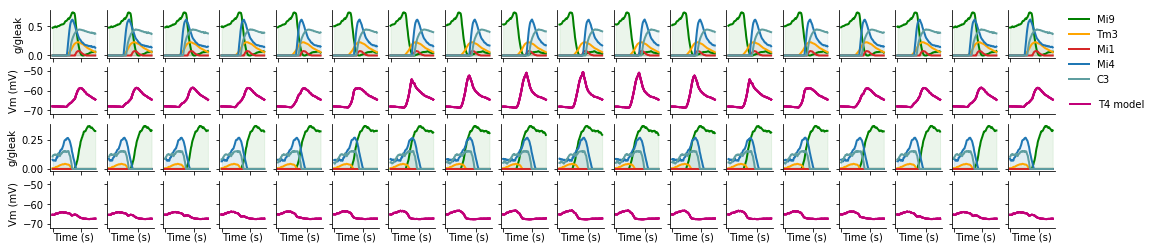

In [2]:
# Extended Data Figure 7:
# Run model:
gMi9, gTm3, gMi1, gMi4, gC3, T4model, T4model_tuning = dir_tuning()

# Shift everything to place PD in the centre:
gMi9 = np.roll(gMi9, 18, axis=1)
gTm3 = np.roll(gTm3, 18, axis=1)
gMi1 = np.roll(gMi1, 18, axis=1)
gMi4 = np.roll(gMi4, 18, axis=1)
gC3 = np.roll(gC3, 18, axis=1)
T4model = np.roll(T4model, 18, axis=1)
gs = [gMi9, gTm3, gMi1, gMi4, gC3]

ds = 15  # downsampling factor for plotting
m = 3250 # margin

fig, ax = plt.subplots(4,18, figsize=(18,4))
time = np.arange(0,len(T4model[0,0,m:-m])/fs,0.001)

labels = ['Mi9', 'Tm3', 'Mi1', 'Mi4', 'C3']
colors = ['g', 'orange', 'C3', 'C0', 'cadetblue']

for idxs, s in enumerate(stims):
    for idxg, g in enumerate(gs):
        for idxd in range(0,36,2):
            ax[0+idxs*2,int(idxd/2)].plot(time[::ds], g[0+idxs,idxd,m:-m:ds], lw=2, c=colors[idxg], label=labels[idxg])
            ax[0+idxs*2,int(idxd/2)].fill_between(time[::ds], g[0+idxs,idxd,m:-m:ds], np.full_like(g[0+idxs,idxd,m:-m:ds], 0), color=colors[idxg], alpha=0.08)
            ax[1+idxs*2,int(idxd/2)].plot(time[::ds], T4model[0+idxs,idxd,m:-m:ds], lw=2, c='#C20078', label='T4 model')
            ax[1+idxs*2,int(idxd/2)].set_ylim(-72, -48)
            if idxd > 0:
                ax[0+idxs*2,int(idxd/2)].tick_params(labelleft=False)
                ax[1+idxs*2,int(idxd/2)].tick_params(labelleft=False)
            if idxs < 2:
                ax[0+idxs*2,int(idxd/2)].tick_params(labelbottom=False)
                ax[1+idxs*2,int(idxd/2)].tick_params(labelbottom=False)
            
ax[0,17].legend(frameon=False, bbox_to_anchor=(1.1, 1.1))
ax[1,17].legend(frameon=False, labels = ['T4 model'], bbox_to_anchor=(3.1, 0.5))

for i in [0,2]:
    ax[i,0].set_ylabel('g/gleak')
    
for i in [1,3]:
    ax[i,0].set_ylabel('Vm (mV)')
    
for i in range(18):
    ax[3,i].set_xlabel('Time (s)')
    
#plt.savefig("edfig7.pdf")